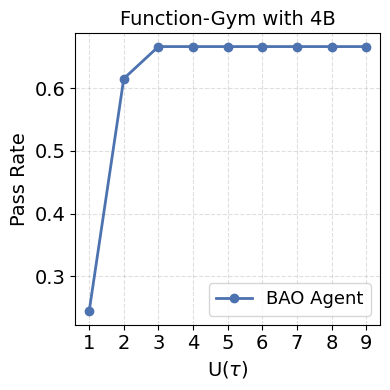

In [5]:
# Self-contained notebook cell (run in an .ipynb)
# ------------------------------------------------
# Plot pass@k curves for GROUPED JSONL files (multiple seeds per method).
#
# For each group:
#   - compute pass@k per seed
#   - plot MEAN curve
#   - visualize STD as SHADED AREA (mean ± std)
#
# pass@k definition:
#   For each entry, consider the first k "answer" actions.
#   If ANY of them is correct ("Your answer is correct!" appears
#   in that answer segment), the entry counts as correct.

import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0) FONT SIZE CONTROL
# ============================================================
FONT_SIZES = {
    "title": 14,
    "axis_label": 14,
    "tick_label": 14,
    "legend": 13,
}

plt.rcParams.update({
    "axes.titlesize": FONT_SIZES["title"],
    "axes.labelsize": FONT_SIZES["axis_label"],
    "xtick.labelsize": FONT_SIZES["tick_label"],
    "ytick.labelsize": FONT_SIZES["tick_label"],
    "legend.fontsize": FONT_SIZES["legend"],
})

# ============================================================
# 1) COLOR CONTROL (single source of truth)
# ============================================================
COLOR_MAP = {
    "BAO Agent": "#4C72B0" , 
}

# -----------------------------
# 2) User-configurable inputs
# -----------------------------
jsonl_groups = [
    {
        "label": "BAO Agent",
        
        "paths": [
            # "PATH_TO_PROJECT_DIR/validation_trajectory/functiongym/Function-Gym-BAO-4B/90.jsonl",
            "/home/lshi40/yihang/project/personalization/userrl/validation_trajectory/functiongym/R2G_Sum-0211-4B-2behaviors-longRL-length-pen-0.01-repeated-pen-0.005/90.jsonl"
        ],
    },
    
]

save_path = None

ks = list(range(1, 10))
CORRECT_MARKER = "Your answer is correct!"

SAVE_FIG = save_path is not None
DPI = 400
SHADE_ALPHA = 0.25

# -----------------------------
# 3) Regex
# -----------------------------
CHOICE_PATTERN = re.compile(r'"choice"\s*:\s*"([A-Za-z_]+)"', re.IGNORECASE)

# -----------------------------
# 4) Helpers
# -----------------------------
def find_answer_spans(text):
    matches = list(CHOICE_PATTERN.finditer(text))
    spans = []
    for i, m in enumerate(matches):
        if m.group(1).lower() != "answer":
            continue
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        spans.append((start, end))
    return spans

def extract_answer_correctness(text):
    spans = find_answer_spans(text)
    return [CORRECT_MARKER in text[s:e] for s, e in spans]

def compute_pass_at_k_single(jsonl_path, ks):
    n = 0
    success = {k: 0 for k in ks}

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            output = json.loads(line).get("output", "")
            flags = extract_answer_correctness(output)
            n += 1
            for k in ks:
                if flags and any(flags[:k]):
                    success[k] += 1

    return np.array([success[k] / n if n > 0 else 0.0 for k in ks])

def aggregate_group(paths, ks):
    curves = []
    for p in paths:
        assert os.path.exists(p), f"Missing file: {p}"
        curves.append(compute_pass_at_k_single(p, ks))
    curves = np.stack(curves, axis=0)
    return curves.mean(axis=0), curves.std(axis=0)

# -----------------------------
# 5) Plot
# -----------------------------
plt.figure(figsize=(4, 4))

for group in jsonl_groups:
    label = group["label"]
    color = COLOR_MAP[label]

    mean_y, std_y = aggregate_group(group["paths"], ks)

    plt.plot(
        ks,
        mean_y,
        marker="o",
        linewidth=2,
        color=color,
        label=label,
    )

plt.xlabel(r"U($\tau$)")
plt.ylabel("Pass Rate")
plt.xticks(ks)
plt.grid(True, linestyle="--", alpha=0.4)
plt.title("Function-Gym with 4B")
plt.legend(frameon=True)

plt.tight_layout()

if SAVE_FIG:
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=DPI, bbox_inches="tight")
    print(f"Saved figure to: {save_path}")

plt.show()
